## IBM OBP Tutorial

In [107]:
import numpy as np
import matplotlib.pyplot as plt
 
from qiskit.primitives import StatevectorEstimator as Estimator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler import CouplingMap
from qiskit.synthesis import LieTrotter
 
from qiskit_addon_utils.problem_generators import generate_xyz_hamiltonian
from qiskit_addon_utils.problem_generators import (
    generate_time_evolution_circuit,
)
from qiskit_addon_utils.slicing import slice_by_gate_types, combine_slices
from qiskit_addon_obp.utils.simplify import OperatorBudget
from qiskit_addon_obp import backpropagate
from qiskit_addon_obp.utils.truncating import setup_budget
 
from qiskit_ibm_runtime.fake_provider import FakeTorino
from qiskit_ibm_runtime import EstimatorV2, EstimatorOptions

In [108]:
# Coupling map of 10 qubits
num_qubits = 10

# Instantiate a linear CouplingMap object
coupling_map = CouplingMap.from_line(10)

In [109]:
# Construct the Hamiltonian
hamiltonian = generate_xyz_hamiltonian(
    coupling_map,
    coupling_constants=(np.pi / 8, np.pi / 4, np.pi / 2),
    ext_magnetic_field=(np.pi / 3, np.pi / 6, np.pi / 9),
)
print(hamiltonian)

SparsePauliOp(['IIIIIIIXXI', 'IIIIIIIYYI', 'IIIIIIIZZI', 'IIIIIXXIII', 'IIIIIYYIII', 'IIIIIZZIII', 'IIIXXIIIII', 'IIIYYIIIII', 'IIIZZIIIII', 'IXXIIIIIII', 'IYYIIIIIII', 'IZZIIIIIII', 'IIIIIIIIXX', 'IIIIIIIIYY', 'IIIIIIIIZZ', 'IIIIIIXXII', 'IIIIIIYYII', 'IIIIIIZZII', 'IIIIXXIIII', 'IIIIYYIIII', 'IIIIZZIIII', 'IIXXIIIIII', 'IIYYIIIIII', 'IIZZIIIIII', 'XXIIIIIIII', 'YYIIIIIIII', 'ZZIIIIIIII', 'IIIIIIIIIX', 'IIIIIIIIIY', 'IIIIIIIIIZ', 'IIIIIIIIXI', 'IIIIIIIIYI', 'IIIIIIIIZI', 'IIIIIIIXII', 'IIIIIIIYII', 'IIIIIIIZII', 'IIIIIIXIII', 'IIIIIIYIII', 'IIIIIIZIII', 'IIIIIXIIII', 'IIIIIYIIII', 'IIIIIZIIII', 'IIIIXIIIII', 'IIIIYIIIII', 'IIIIZIIIII', 'IIIXIIIIII', 'IIIYIIIIII', 'IIIZIIIIII', 'IIXIIIIIII', 'IIYIIIIIII', 'IIZIIIIIII', 'IXIIIIIIII', 'IYIIIIIIII', 'IZIIIIIIII', 'XIIIIIIIII', 'YIIIIIIIII', 'ZIIIIIIIII'],
              coeffs=[0.39269908+0.j, 0.78539816+0.j, 1.57079633+0.j, 0.39269908+0.j,
 0.78539816+0.j, 1.57079633+0.j, 0.39269908+0.j, 0.78539816+0.j,
 1.57079633+0.j, 0.39269908+0.j, 0.

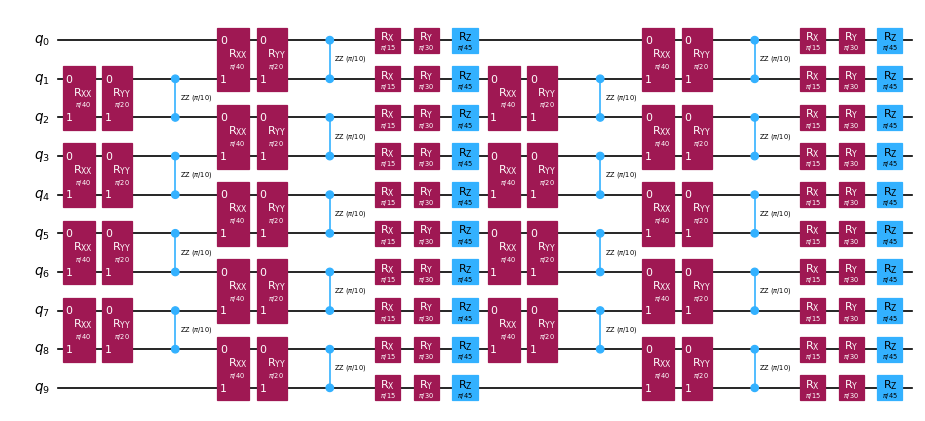

In [110]:
circuit = generate_time_evolution_circuit(
    hamiltonian,
    time=0.2,
    synthesis=LieTrotter(reps=2),
)
circuit.draw("mpl", style="iqp", scale=0.6)

In [111]:
# Slicing the circuit for OBP
slices = slice_by_gate_types(circuit)
print(f"Separated the circuit into {len(slices)} slices.")

Separated the circuit into 18 slices.


In [112]:
# Constrain how large the operator may grow during backpropagation
op_budget = OperatorBudget(max_qwc_groups=8)

In [113]:
observable = SparsePauliOp.from_sparse_list(
    [("Z", [i], 1 / num_qubits) for i in range(num_qubits)],
    num_qubits=num_qubits,
)
observable

SparsePauliOp(['IIIIIIIIIZ', 'IIIIIIIIZI', 'IIIIIIIZII', 'IIIIIIZIII', 'IIIIIZIIII', 'IIIIZIIIII', 'IIIZIIIIII', 'IIZIIIIIII', 'IZIIIIIIII', 'ZIIIIIIIII'],
              coeffs=[0.1+0.j, 0.1+0.j, 0.1+0.j, 0.1+0.j, 0.1+0.j, 0.1+0.j, 0.1+0.j, 0.1+0.j,
 0.1+0.j, 0.1+0.j])

Backpropagated 6 slices.
New observable has 60 terms, which can be combined into 6 groups.
Note that backpropagating one more slice would result in 114 terms across 12 groups.
The remaining circuit after backpropagation looks as follows:


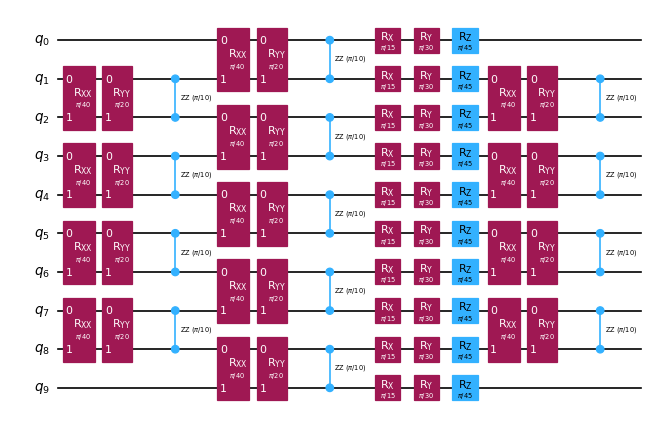

In [114]:
# Backpropagate slices onto the observable
bp_obs, remaining_slices, metadata = backpropagate(
    observable, slices, operator_budget=op_budget
)
# Recombine the slices remaining after backpropagation
bp_circuit = combine_slices(remaining_slices)

print(f"Backpropagated {metadata.num_backpropagated_slices} slices.")
print(
    f"New observable has {len(bp_obs.paulis)} terms, which can be combined into {len(bp_obs.group_commuting(qubit_wise=True))} groups."
)
print(
    f"Note that backpropagating one more slice would result in {metadata.backpropagation_history[-1].num_paulis[0]} terms "
    f"across {metadata.backpropagation_history[-1].num_qwc_groups} groups."
)
print("The remaining circuit after backpropagation looks as follows:")
bp_circuit.draw("mpl", fold=-1, scale=0.6)

In [115]:
# Setting an error bound for the error budget for each slice
truncation_error_budget = setup_budget(max_error_per_slice=0.005)

Backpropagated 7 slices.
New observable has 82 terms, which can be combined into 8 groups.
After truncation, the error in our observable is bounded by 3.266e-02
Note that backpropagating one more slice would result in 114 terms across 12 groups.
The remaining circuit after backpropagation looks as follows:


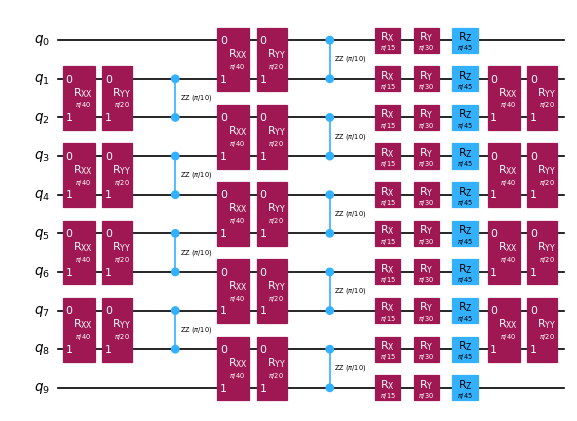

In [116]:
# Run the same experiment but truncate observable terms with small coefficients
bp_obs_trunc, remaining_slices_trunc, metadata = backpropagate(
    observable,
    slices,
    operator_budget=op_budget,
    truncation_error_budget=truncation_error_budget,
)
 
# Recombine the slices remaining after backpropagation
bp_circuit_trunc = combine_slices(
    remaining_slices_trunc, include_barriers=False
)
 
print(f"Backpropagated {metadata.num_backpropagated_slices} slices.")
print(
    f"New observable has {len(bp_obs_trunc.paulis)} terms, which can be combined into {len(bp_obs_trunc.group_commuting(qubit_wise=True))} groups.\n"
    f"After truncation, the error in our observable is bounded by {metadata.accumulated_error(0):.3e}"
)
print(
    f"Note that backpropagating one more slice would result in {metadata.backpropagation_history[-1].num_paulis[0]} terms "
    f"across {metadata.backpropagation_history[-1].num_qwc_groups} groups."
)
print("The remaining circuit after backpropagation looks as follows:")
bp_circuit_trunc.draw("mpl", scale=0.6)

In [117]:
# Setting up the backend
backend = FakeTorino()

# Transpilation
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)

# Transpile original experiment
circuit_isa = pm.run(circuit)
observable_isa = observable.apply_layout(circuit_isa.layout)
 
# Transpile backpropagated experiment
bp_circuit_isa = pm.run(bp_circuit)
bp_obs_isa = bp_obs.apply_layout(bp_circuit_isa.layout)
 
# Transpile the backpropagated experiment with truncated observable terms
bp_circuit_trunc_isa = pm.run(bp_circuit_trunc)
bp_obs_trunc_isa = bp_obs_trunc.apply_layout(bp_circuit_trunc_isa.layout)

# Create PUBs for all 3 case
pub = (circuit_isa, observable_isa)
bp_pub = (bp_circuit_isa, bp_obs_isa)
bp_trunc_pub = (bp_circuit_trunc_isa, bp_obs_trunc_isa)

In [118]:
ideal_estimator = Estimator()
 
# Run the experiments using Estimator primitive to obtain the exact outcome
result_exact = (
    ideal_estimator.run([(circuit, observable)]).result()[0].data.evs.item()
)
print(f"Exact expectation value: {result_exact}")

Exact expectation value: 0.8871244838989416


In [119]:
options = EstimatorOptions()
options.default_precision = 0.011
# options.resilience_level = 2 # not needed when running on local sim
 
estimator = EstimatorV2(mode=backend, options=options)

job = estimator.run([pub, bp_pub, bp_trunc_pub])

In [120]:
result_no_bp = job.result()[0].data.evs.item()
result_bp = job.result()[1].data.evs.item()
result_bp_trunc = job.result()[2].data.evs.item()
 
std_no_bp = job.result()[0].data.stds.item()
std_bp = job.result()[1].data.stds.item()
std_bp_trunc = job.result()[2].data.stds.item()

In [121]:
print(
    f"Expectation value without backpropagation: {result_no_bp} ± {std_no_bp}"
)
print(f"Backpropagated expectation value: {result_bp} ± {std_bp}")
print(
    f"Backpropagated expectation value with truncation: {result_bp_trunc} ± {std_bp_trunc}"
)

Expectation value without backpropagation: 0.7155474894131881 ± 0.007616659501279884
Backpropagated expectation value: 0.7457749932330918 ± 0.011041097627505648
Backpropagated expectation value with truncation: 0.7533700600644839 ± 0.011707476529032259


Text(0, 0.5, '$M_Z$')

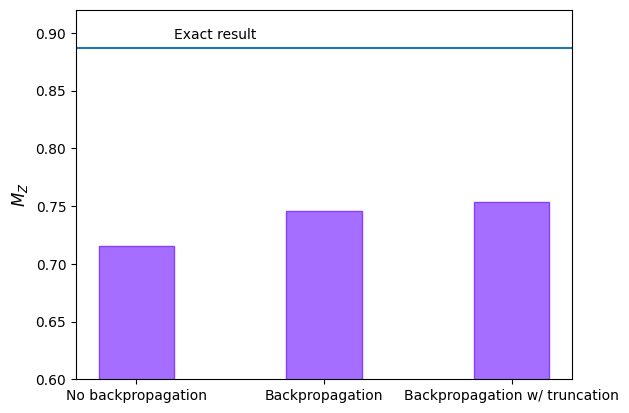

In [122]:
methods = [
    "No backpropagation",
    "Backpropagation",
    "Backpropagation w/ truncation",
]
values = [result_no_bp, result_bp, result_bp_trunc]
stds = [std_no_bp, std_bp, std_bp_trunc]
 
ax = plt.gca()
plt.bar(methods, values, color="#a56eff", width=0.4, edgecolor="#8a3ffc")
plt.axhline(result_exact)
ax.set_ylim([0.6, 0.92])
plt.text(0.2, 0.895, "Exact result")
ax.set_ylabel(r"$M_Z$", fontsize=12)

## Testing OBP on an 8-qubit Fermi-Hubbard model

In [123]:
import numpy as np
import time
from qiskit import QuantumCircuit

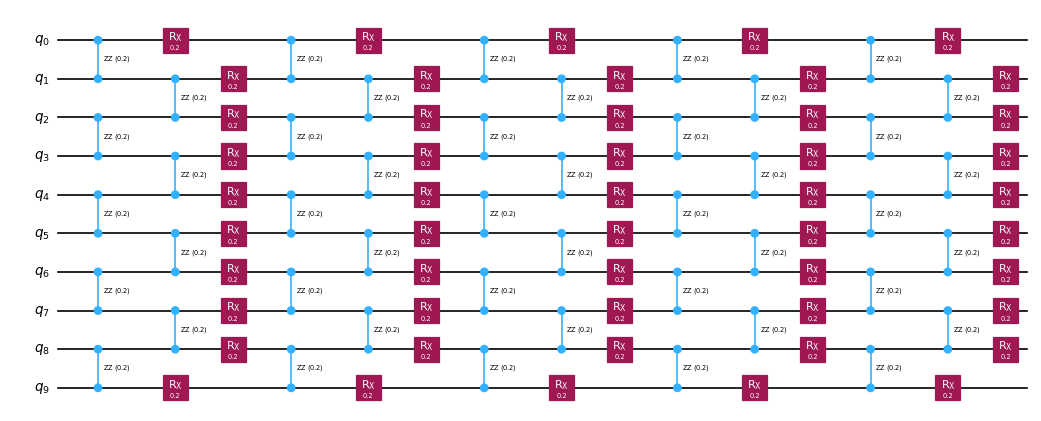

In [124]:
num_qubits = 10
qc = QuantumCircuit(num_qubits)

J = 1
h = 1
dt = 0.1 # trotter step size
num_steps = 5 #total trotter steps

for _ in range(num_steps):
    # Even-Odd pattern for ZZ interactions
    for i in range(0, num_qubits - 1, 2):
        qc.rzz(2 * J * dt, i, i + 1)
    for i in range(1, num_qubits - 1, 2):
        qc.rzz(2 * J * dt, i, i + 1)
        
    # X rotations
    for i in range(num_qubits):
        qc.rx(2 * h * dt, i)

qc.draw("mpl", fold=-1, scale=0.6)

In [125]:
# Defining the observable
pauli_string = "I" * (num_qubits - 5) + "Z" + "I" * 4
observable = SparsePauliOp.from_list([(pauli_string, 1.0)])
print(f"Observable: {observable.paulis[0]}\n")

Observable: IIIIIZIIII



In [126]:
ideal_estimator = Estimator()
 
# Run the experiments using Estimator primitive to obtain the exact outcome
start_time = time.time()
result_exact = (
    ideal_estimator.run([(qc, observable)]).result()[0].data.evs.item()
)
exact_time = time.time() - start_time
print(f"Exact Simulation Time: {exact_time:.5f} seconds")
print(f"Exact expectation value: {result_exact}")

Exact Simulation Time: 0.00687 seconds
Exact expectation value: 0.6539027579465844


In [127]:
# Slicing the circuit for OBP
slices = slice_by_gate_types(qc)
print(f"Separated the circuit into {len(slices)} slices.\n")

Separated the circuit into 15 slices.



In [128]:
# On FakeTorino backend
backend = FakeTorino()
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)

isa_qc = pm.run(qc)
isa_obs = observable.apply_layout(isa_qc.layout)

print(f"Compiled Circuit Depth: {isa_qc.depth()}")

Compiled Circuit Depth: 105


In [129]:
options = EstimatorOptions()
options.default_precision = 0.005

In [130]:
noisy_estimator = EstimatorV2(mode=backend, options=options)
noisy_pub = (isa_qc, isa_obs)

start_time = time.time()
noisy_result = noisy_estimator.run([noisy_pub]).result()[0]
noisy_time = time.time() - start_time
noisy_expval = noisy_result.data.evs

print(f"Noisy Expectation Value: {noisy_expval:.5f}")
print(f"Noisy Simulation Time:   {noisy_time:.4f} seconds")
print(f"Total Error from Exact:  {abs(result_exact - noisy_expval):.5f}")

Noisy Expectation Value: 0.51740
Noisy Simulation Time:   6.1663 seconds
Total Error from Exact:  0.13650


In [131]:
# Experimenting with different QWC values
qwc_values = [2, 4, 8, 16, 32]
runtimes = []
errors = []

for max_qwc in qwc_values:
    print(f"Testing max_qwc = {max_qwc}")
    
    op_budget = OperatorBudget(max_qwc_groups=max_qwc)
    # Turned off truncation so we only measure quantum hardware noise
    trunc_budget = setup_budget(max_error_per_slice=0.0)
    
    start_classical = time.time()
    bp_obs, remaining_slices, metadata = backpropagate(
        observable, 
        slices, 
        operator_budget=op_budget, 
        truncation_error_budget=trunc_budget)
    classical_time = time.time() - start_classical
    runtimes.append(classical_time)
    
    u_q = combine_slices(remaining_slices, include_barriers=False)
        
    isa_u_q = pm.run(u_q)
    isa_obs = bp_obs.apply_layout(isa_u_q.layout)
    
    noisy_result = estimator.run([(isa_u_q, isa_obs)]).result()[0]
    noisy_expval = noisy_result.data.evs
    
    error = abs(result_exact - noisy_expval)
    errors.append(error)
    
    print(f"Classical OBP Time:      {classical_time:.4f}s")
    print(f"Remaining Quantum Depth: {isa_u_q.depth()}")
    print(f"Error from Exact:        {error:.5f}\n")

Testing max_qwc = 2
Classical OBP Time:      0.0057s
Remaining Quantum Depth: 103
Error from Exact:        0.14244

Testing max_qwc = 4
Classical OBP Time:      0.0066s
Remaining Quantum Depth: 85
Error from Exact:        0.13440

Testing max_qwc = 8
Classical OBP Time:      0.0070s
Remaining Quantum Depth: 85
Error from Exact:        0.12192

Testing max_qwc = 16
Classical OBP Time:      0.0100s
Remaining Quantum Depth: 83
Error from Exact:        0.11658

Testing max_qwc = 32
Classical OBP Time:      0.0206s
Remaining Quantum Depth: 65
Error from Exact:        0.11159



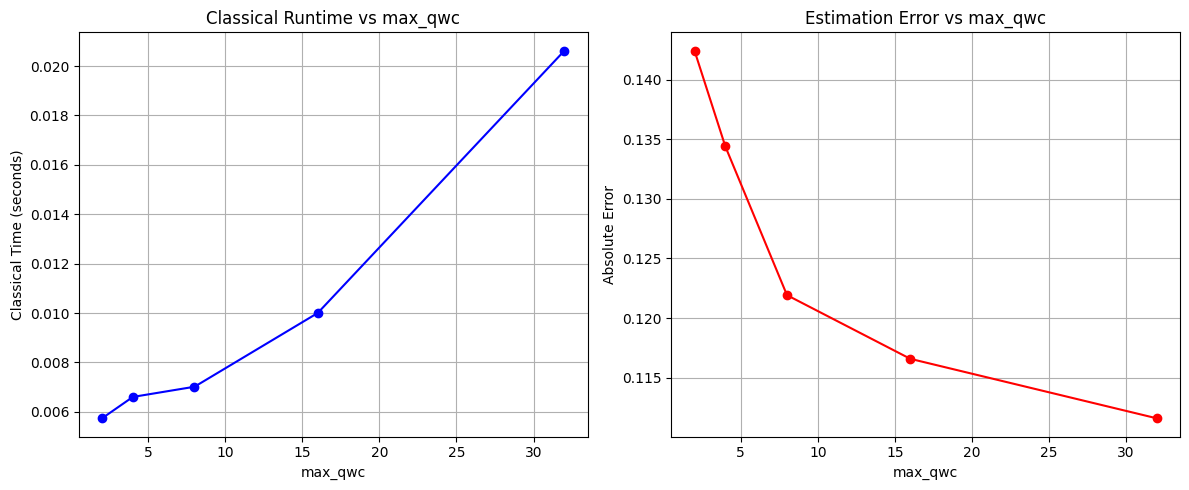

In [132]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(qwc_values, runtimes, marker='o', color='blue')
ax1.set_title('Classical Runtime vs max_qwc')
ax1.set_xlabel('max_qwc')
ax1.set_ylabel('Classical Time (seconds)')
ax1.grid(True)

ax2.plot(qwc_values, errors, marker='o', color='red')
ax2.set_title('Estimation Error vs max_qwc')
ax2.set_xlabel('max_qwc')
ax2.set_ylabel('Absolute Error')
ax2.grid(True)

plt.tight_layout()
plt.show()

In [133]:
# Trying out different truncation error budgets
trunc_values = [0.001, 0.01, 0.05]
pauli_counts = []
errors = []

for trunc_val in trunc_values:
    print(f"Testing max_error_per_slice = {trunc_val}")
    
    # set max_qwc to a fairly high value
    op_budget = OperatorBudget(max_qwc_groups=10)
    trunc_budget = setup_budget(max_error_per_slice=trunc_val)
    
    bp_obs, remaining_slices, metadata = backpropagate(
        observable, 
        slices, 
        operator_budget=op_budget, 
        truncation_error_budget=trunc_budget)
    
    # Record how many Pauli strings survived the truncation
    num_paulis = len(bp_obs.paulis)
    pauli_counts.append(num_paulis)
    
    if not remaining_slices: # If the list is empty
        print("U_Q is just Identity.")
        u_q = QuantumCircuit(num_qubits) # Empty circuit
    else:
        u_q = combine_slices(remaining_slices, include_barriers=False)
    isa_u_q = pm.run(u_q)
    isa_obs = bp_obs.apply_layout(isa_u_q.layout)
    
    noisy_result = estimator.run([(isa_u_q, isa_obs)]).result()[0]
    noisy_expval = noisy_result.data.evs
    
    error = abs(result_exact - noisy_expval)
    errors.append(error)
    
    print(f"Remaining Pauli Strings: {num_paulis}")
    print(f"Remaining Quantum Depth: {isa_u_q.depth()}")
    print(f"Error from Exact:        {error:.5f}\n")

Testing max_error_per_slice = 0.001
Remaining Pauli Strings: 13
Remaining Quantum Depth: 63
Error from Exact:        0.12142

Testing max_error_per_slice = 0.01
Remaining Pauli Strings: 14
Remaining Quantum Depth: 13
Error from Exact:        0.08915

Testing max_error_per_slice = 0.05
U_Q is just Identity.
Remaining Pauli Strings: 4
Remaining Quantum Depth: 0
Error from Exact:        0.17752

